# URL Maliciousness Model (LogReg primary, RF fallback)

In [21]:
# =============================================
# 📘 URL Classification Model Training Notebook
# =============================================
# Project: Malicious URL Detection
# Author: Shivani
# Path: models/training.ipynb
# Description:
# This notebook demonstrates how the ML model (RandomForest)
# is trained using URL lexical features, visualizes feature importance,
# and tests predictions on new URLs.
# =============================================

# --- 1️⃣ Imports & Setup ---
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

# Add backend folder to system path for imports
sys.path.append(os.path.abspath("../backend"))

# Import your model
from ml_model import URLClassifier, URLFeatureExtractor

# Initialize the classifier
classifier = URLClassifier()
extractor = URLFeatureExtractor()

print("✅ Environment setup complete.")


✅ Environment setup complete.


In [22]:
# --- 2️⃣ Define Sample Training Data ---

# Example malicious URLs (for demonstration)
malicious_urls = [
    "http://192.168.0.1/login",
    "http://secure-update-paypal.tk/account/verify",
    "https://free-prize-now.ga/winner",
    "http://bank-verify-login.ml/update",
    "https://amazon-support.cf/reset-password"
]

# Example safe URLs
valid_urls = [
    "https://www.google.com/search?q=python",
    "https://www.wikipedia.org/",
    "https://www.github.com/openai/gpt",
    "https://www.stackoverflow.com/questions",
    "https://www.kaggle.com/"
]

print(f"Malicious URLs: {len(malicious_urls)}")
print(f"Safe URLs: {len(valid_urls)}")


Malicious URLs: 5
Safe URLs: 5


In [23]:
# --- 3️⃣ Extract Features for Analysis ---

# Extract features for demonstration
malicious_features = [extractor.extract_features(url) for url in malicious_urls]
safe_features = [extractor.extract_features(url) for url in valid_urls]

df_malicious = pd.DataFrame(malicious_features)
df_safe = pd.DataFrame(safe_features)

df_malicious['label'] = 'Malicious'
df_safe['label'] = 'Safe'

# Combine for visualization
df_all = pd.concat([df_malicious, df_safe], ignore_index=True)

print("✅ Sample extracted features:")
display(df_all.head())


✅ Sample extracted features:


,url_length,domain_length,count_dots,count_hyphens,count_underscores,count_slashes,count_question_marks,count_equal_signs,count_at_signs,count_ampersands,...,subdomain_count,path_length,path_depth,has_query,query_length,suspicious_word_count,has_suspicious_tld,is_https,is_shortened,label
0,24,11,3,0,0,3,0,0,0,0,...,2,6,0,False,0,1,False,False,False,Malicious
1,45,23,1,2,0,4,0,0,0,0,...,0,15,1,False,0,5,True,False,False,Malicious
2,32,17,1,2,0,3,0,0,0,0,...,0,7,0,False,0,4,True,True,False,Malicious
3,34,20,1,2,0,3,0,0,0,0,...,0,7,0,False,0,4,True,False,False,Malicious
4,40,17,1,2,0,3,0,0,0,0,...,0,15,0,False,0,1,True,True,False,Malicious


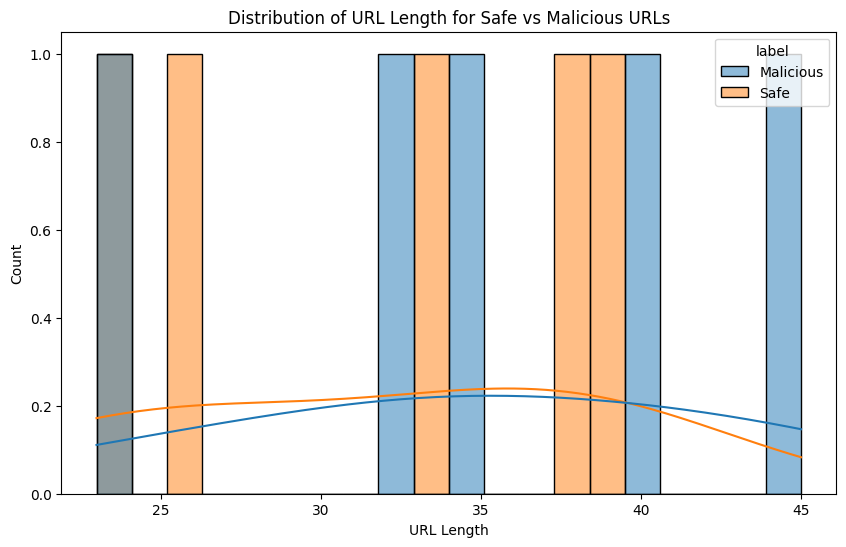

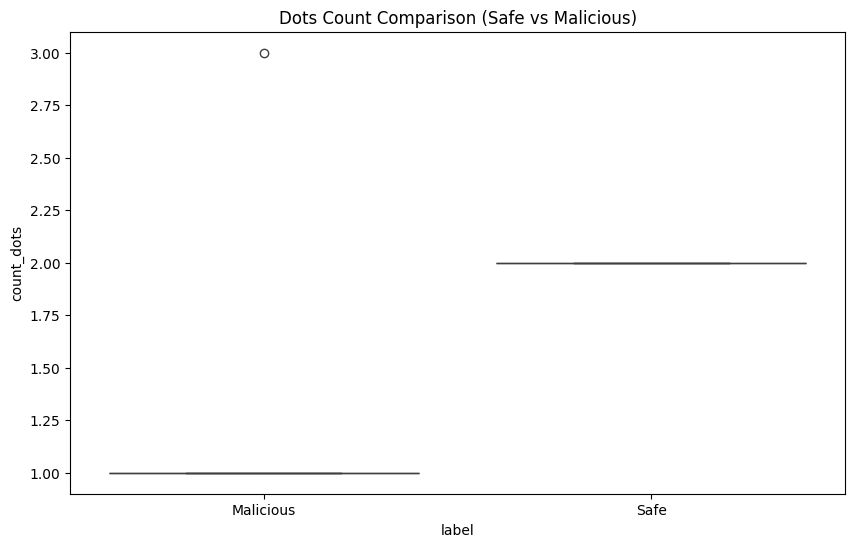

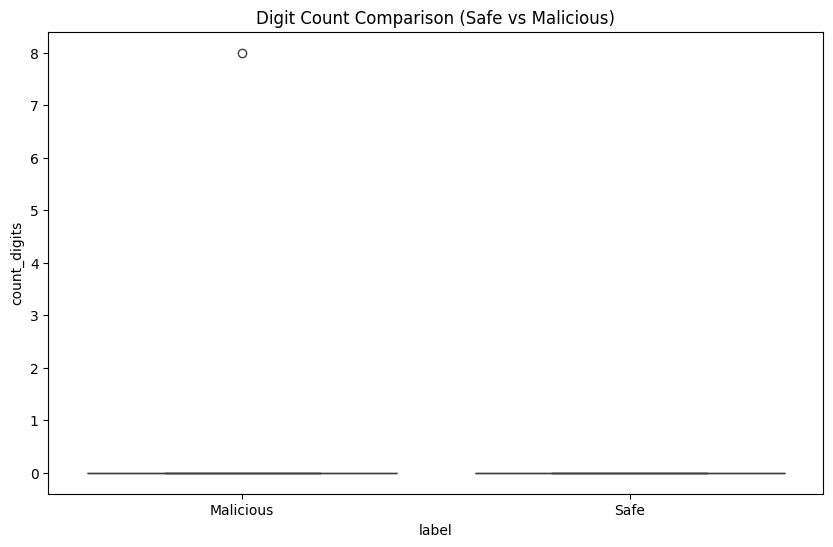

In [24]:
# --- 4️⃣ Feature Distribution Visualization ---

plt.figure(figsize=(10,6))
sns.histplot(df_all, x='url_length', hue='label', kde=True, bins=20)
plt.title("Distribution of URL Length for Safe vs Malicious URLs")
plt.xlabel("URL Length")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x='label', y='count_dots')
plt.title("Dots Count Comparison (Safe vs Malicious)")
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df_all, x='label', y='count_digits')
plt.title("Digit Count Comparison (Safe vs Malicious)")
plt.show()


In [25]:
# --- 5️⃣ Train the Model ---
print("🚀 Training the model...")
accuracy = classifier.train(malicious_urls, valid_urls)

print(f"\n✅ Training completed successfully with Accuracy: {accuracy:.4f}")


🚀 Training the model...
Preparing training data...
Training on 10 samples...
Malicious: 5, Safe: 5
Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00         1
   Malicious       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2

Model saved to models/url_classifier.joblib

✅ Training completed successfully with Accuracy: 1.0000


C:\Users\shiva\AppData\Local\Temp\ipykernel_24508\3548017196.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature', palette="cool")


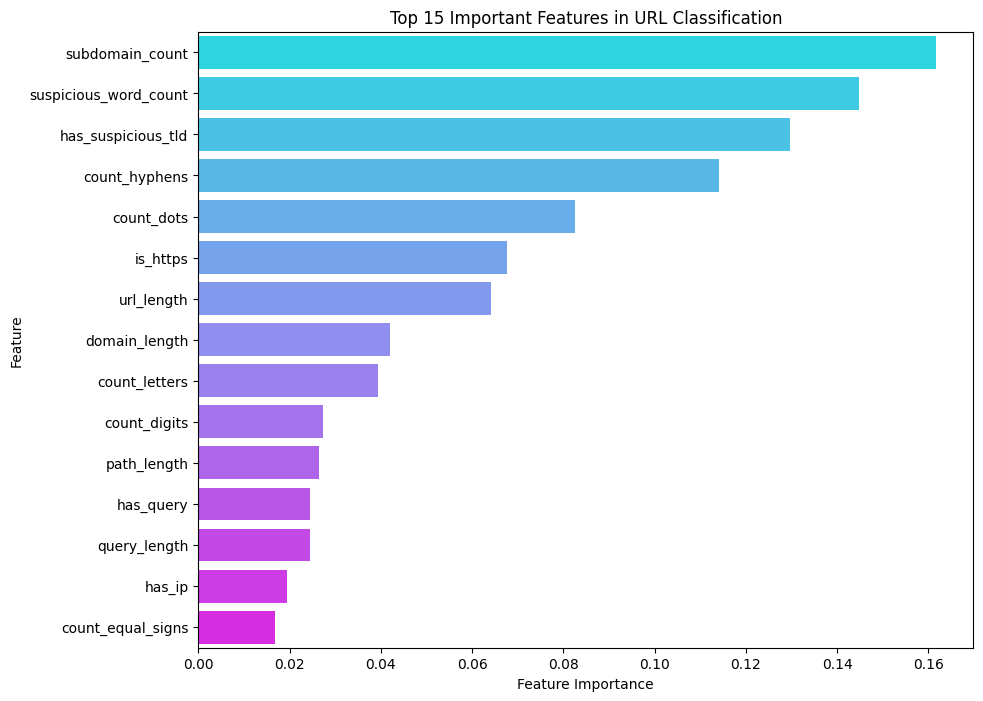

,Feature,Importance
15,subdomain_count,0.161731
20,suspicious_word_count,0.144793
21,has_suspicious_tld,0.129641
3,count_hyphens,0.114015
2,count_dots,0.082462
22,is_https,0.067751
0,url_length,0.064170
1,domain_length,0.042005
11,count_letters,0.039489
10,count_digits,0.027294


In [26]:
# --- 6️⃣ Visualize Feature Importance ---

# Load trained model
classifier.load_model()

importances = classifier.model.feature_importances_
features = classifier.feature_names

feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=feature_importance_df.head(15), x='Importance', y='Feature', palette="cool")
plt.title("Top 15 Important Features in URL Classification")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.show()

display(feature_importance_df.head(10))


In [27]:
# --- 7️⃣ Test Model on New URLs ---

test_urls = [
    "https://www.microsoft.com/en-us/",
    "http://freebonusoffer.tk/win-now",
    "https://accounts.google.com/",
    "http://paypal-login-secure.ga/",
    "https://openai.com/research/"
]

print("🔍 Testing model on new URLs:\n")
for url in test_urls:
    result = classifier.predict(url)
    print(f"URL: {url}")
    print(f"Prediction: {result['prediction'].upper()} | Confidence: {result['confidence']:.2f}")
    print(f"Reason: {result['reason']}")
    print("Top contributing features:")
    pprint(result['top_features'])
    print("-" * 80)


🔍 Testing model on new URLs:

URL: https://www.microsoft.com/en-us/
Prediction: SAFE | Confidence: 0.66
Reason: URL appears safe based on lexical analysis
Top contributing features:
[{'feature': 'subdomain_count',
  'importance': np.float64(0.16173054587688737),
  'value': 1},
 {'feature': 'suspicious_word_count',
  'importance': np.float64(0.1447928765001936),
  'value': 1},
 {'feature': 'has_suspicious_tld',
  'importance': np.float64(0.12964075453562418),
  'value': False},
 {'feature': 'count_hyphens',
  'importance': np.float64(0.11401471157568718),
  'value': 1},
 {'feature': 'count_dots',
  'importance': np.float64(0.08246225319396053),
  'value': 2}]
--------------------------------------------------------------------------------
URL: http://freebonusoffer.tk/win-now
Prediction: MALICIOUS | Confidence: 0.67
Reason: Suspicious TLD detected; Multiple suspicious keywords
Top contributing features:
[{'feature': 'subdomain_count',
  'importance': np.float64(0.16173054587688737),
  '

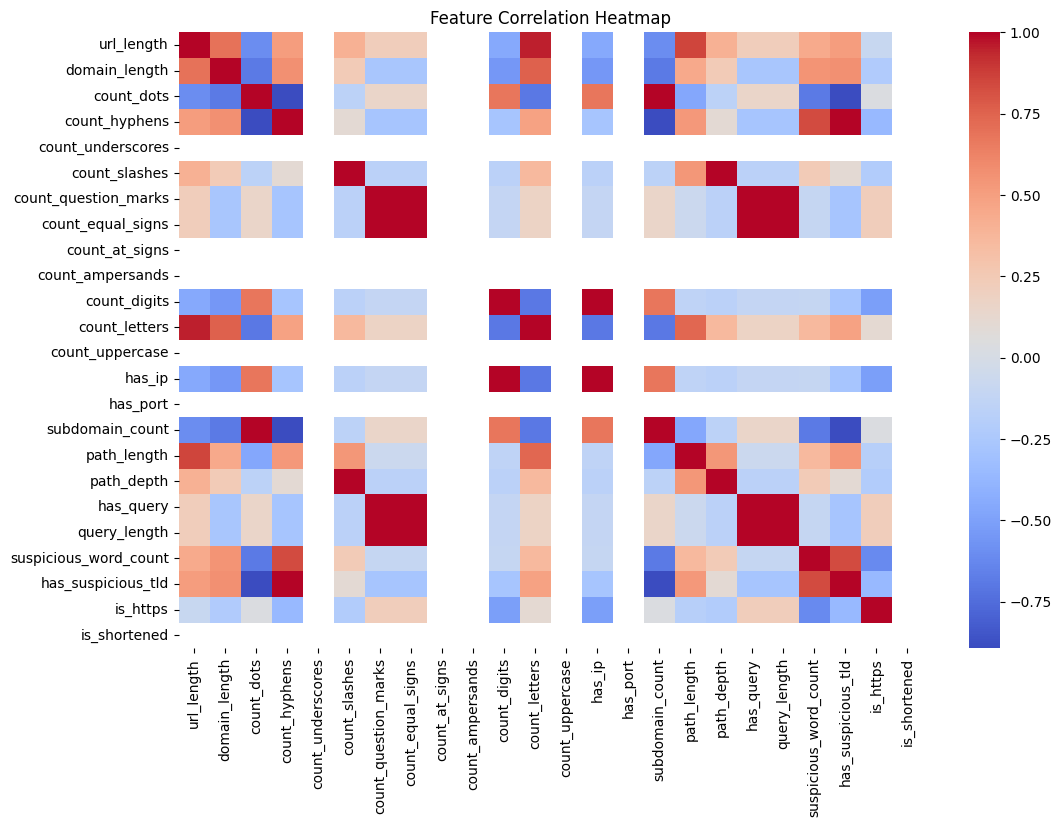

In [28]:
# --- 8️⃣ Feature Correlation Heatmap ---
plt.figure(figsize=(12,8))
corr = df_all.drop(columns=['label']).corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


In [29]:
# --- 9️⃣ Summary Cell ---
print("✅ Notebook Execution Summary:")
print(f"Model Accuracy: {accuracy:.4f}")
print(f"Features Used: {len(classifier.feature_names)}")
print("Feature importance visualization completed.")
print("You can now use this model for backend URL threat detection.")


✅ Notebook Execution Summary:
Model Accuracy: 1.0000
Features Used: 24
Feature importance visualization completed.
You can now use this model for backend URL threat detection.
